In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, chronological_split, fit_scaler, apply_scaler, inverse_transform_column
from src.feature_engineering import build_features
from src.sequence_builder import create_sequences_for_all_splits
from src.evaluation.metrics import evaluate_all
from src.config import MODEL_FEATURE_COLUMNS, TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON

DEV_LOOKBACK = 72  # temporary, for fast iteration — NOT the final 168

df_raw = load_raw_data()
df_clean = clean_raw_data(df_raw)
df_features = build_features(df_clean)
splits = chronological_split(df_features)

scale_columns = MODEL_FEATURE_COLUMNS + [TARGET_COL]
scaler = fit_scaler(splits.train, scale_columns)

train_scaled = apply_scaler(splits.train, scaler, scale_columns)
val_scaled = apply_scaler(splits.val, scaler, scale_columns)
test_scaled = apply_scaler(splits.test, scaler, scale_columns)

sequences = create_sequences_for_all_splits(train_scaled, val_scaled, test_scaled, MODEL_FEATURE_COLUMNS)
X_train, y_train_scaled = sequences["train"]
X_val, y_val_scaled = sequences["val"]
X_test, y_test_scaled = sequences["test"]

print("Ready:", X_train.shape, X_val.shape, X_test.shape)

2026-09-11 17:57:32 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-11 17:57:32 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
2026-09-11 17:57:32 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-11 17:57:32 | INFO     | src.feature_engineering | Added national weather averages: temp_avg, humidity_avg, precip_avg, wind_avg
2026-09-11 17:57:32 | INFO     | src.feature_engineering | Added calendar features and cyclical encodings
2026-09-11 17:57:33 | INFO     | src.feature_engineering | Added lag features: ['lag_1', 'lag_24', 'lag_48', 'lag_168']
2026-09-11 17:57:33 | INFO     | src.feature_engineering | Added rolling features: rolling_mean_24, rolling_std_24, rolling_mean_168
2026-09-11 17:57:33 | INFO     | src.feature_engineering | Feature engineering complete: 48048 rows before, 47880 rows

In [3]:
import os
import torch
torch.set_num_threads(os.cpu_count())

from src.models.gru import GRUForecaster
from src.training.trainer import train_model, predict

gru_model = GRUForecaster(num_features=X_train.shape[2])
gru_history = train_model(gru_model, X_train, y_train_scaled, X_val, y_val_scaled, epochs=10)

print("Epochs trained:", gru_history["epochs_trained"])
print("Parameters:", gru_history["num_parameters"])
print("Training time (s):", round(gru_history["training_time_seconds"], 1))

2026-09-11 17:57:54 | INFO     | src.training.trainer | Training GRUForecaster | 18072 parameters | device=cpu
2026-09-11 17:57:55 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:58:40 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 17:58:56 | INFO     | src.training.trainer | Epoch 1/10 | train_loss=0.050236 | val_loss=0.014656
2026-09-11 17:58:56 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 17:59:33 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 18:00:04 | INFO     | src.training.trainer | Epoch 2/10 | train_loss=0.008296 | val_loss=0.007274
2026-09-11 18:00:04 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 18:01:13 | INFO     | src.training.trainer |   batch 100/131
2026-09-11 18:01:31 | INFO     | src.training.trainer | Epoch 3/10 | train_loss=0.005233 | val_loss=0.006079
2026-09-11 18:01:31 | INFO     | src.training.trainer |   batch 0/131
2026-09-11 18:02:17 | INFO     | src.training.trainer |   batch 10

In [4]:
from src.evaluation.metrics import evaluate_all
from src.preprocessing import inverse_transform_column
from src.config import TARGET_COL

y_pred_test_scaled = predict(gru_model, X_test)
y_true_gru = inverse_transform_column(y_test_scaled, scaler, scale_columns, TARGET_COL)
y_pred_gru = inverse_transform_column(y_pred_test_scaled, scaler, scale_columns, TARGET_COL)

gru_metrics = evaluate_all(y_true_gru, y_pred_gru)
print("GRU:", gru_metrics)

GRU: {'MAE': 71.90509986000302, 'RMSE': 97.20509569978887, 'MAPE': 6.156141076055723, 'sMAPE': 6.052414933450456, 'R2': 0.7228157616784869}


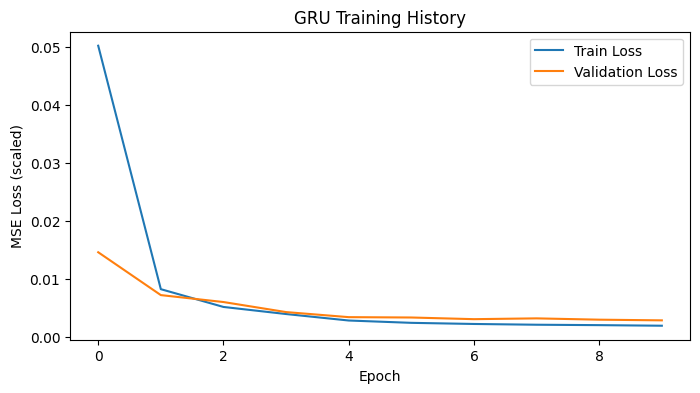

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gru_history["train_loss"], label="Train Loss")
ax.plot(gru_history["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled)")
ax.set_title("GRU Training History")
ax.legend()
plt.show()

In [6]:
import json
from pathlib import Path
import pandas as pd

experiments_path = Path.cwd().parent / "experiments" / "model_comparison.json"
with open(experiments_path) as f:
    all_results = json.load(f)

all_results["GRU"] = {
    **gru_metrics,
    "training_time_seconds": gru_history["training_time_seconds"],
    "num_parameters": gru_history["num_parameters"],
}
with open(experiments_path, "w") as f:
    json.dump(all_results, f, indent=2)

comparison = pd.DataFrame({
    "LSTM (1-layer)": all_results["LSTM"],
    "GRU": gru_metrics,
}).T[["MAE", "RMSE", "MAPE", "sMAPE", "R2"]]
print(comparison)
print("\nSaved GRU to experiments/model_comparison.json")

                      MAE       RMSE      MAPE     sMAPE        R2
LSTM (1-layer)  67.422624  93.767627  5.773968  5.654699  0.742073
GRU             71.905100  97.205096  6.156141  6.052415  0.722816

Saved GRU to experiments/model_comparison.json
